In [1]:
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np
import torch

In [7]:
waymo_preprocessed_dir = Path("./data/scenario_dreamer_ae_preprocess_waymo")
nuplan_preprocessed_dir = Path("./data/scenario_dreamer_ae_preprocess_nuplan")
split = "train"

waymo_preprocessed_dir_split = waymo_preprocessed_dir / split
nuplan_preprocessed_dir_split = nuplan_preprocessed_dir / split

assert waymo_preprocessed_dir_split.exists(), f"Directory {waymo_preprocessed_dir_split} does not exist."
assert nuplan_preprocessed_dir_split.exists(), f"Directory {nuplan_preprocessed_dir_split} does not exist."

In [8]:
waymo_files = sorted(waymo_preprocessed_dir_split.glob("*.pkl"))
len(waymo_files)

973984

In [4]:
idx = 0

waymo_fpath = waymo_files[idx]
waymo_fpath

PosixPath('data/scenario_dreamer_ae_preprocess_waymo/test/testing.tfrecord-00000-of-00150_0_0_6.pkl')

In [5]:
with open(waymo_files[idx], "rb") as f:
    data = pickle.load(f)
    
for key, value in data.items():
    if isinstance(value, int):
        print(f"{key}: {value}")
    else:
        print(f"{key}: {value.shape}")

idx: 0
lg_type: 0
scene_timestep: ()
num_agents: 5
num_lanes: 12
road_points: (12, 20, 2)
agent_states: (5, 7)
agent_types: (5, 3)
edge_index_lane_to_lane: torch.Size([2, 144])
edge_index_agent_to_agent: torch.Size([2, 25])
edge_index_lane_to_agent: torch.Size([2, 60])
road_connection_types: (144, 6)


/tmp/ipykernel_984966/1828421356.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


/tmp/ipykernel_984966/1838219729.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


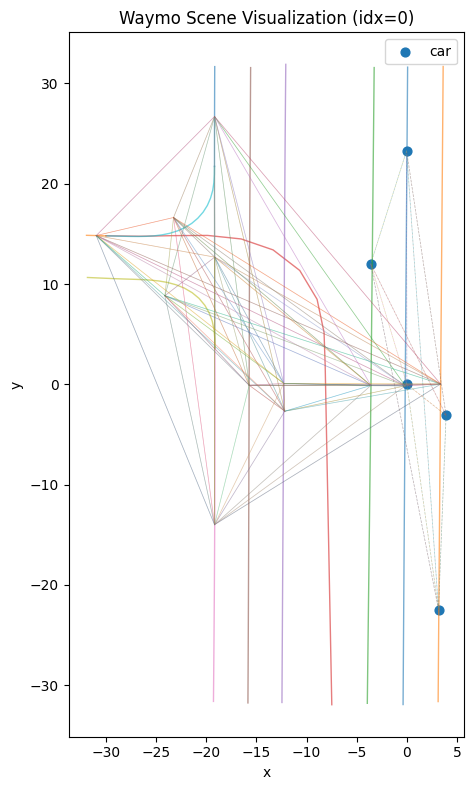

In [6]:
def _to_numpy(x):
    """把 int / numpy / torch.Tensor 统一成 numpy."""
    if isinstance(x, np.ndarray):
        return x
    # if TORCH_AVAILABLE and isinstance(x, torch.Tensor):
    #     return x.detach().cpu().numpy()
    return np.array(x)

def visualize_scene_dict(
    data: dict,
    show_lane_edges: bool = True,
    show_agent_edges: bool = False,
    figsize: tuple = (8, 8),
    title: str = None,
):
    """
    用 matplotlib 可视化一个场景：
    - lane polyline
    - agent 位置（按类型区分）
    - 可选：lane-to-lane / agent-to-agent 边
    """
    road_points = _to_numpy(data["road_points"])          # (num_lanes, num_points, 2)
    agent_states = _to_numpy(data["agent_states"])        # (num_agents, 7) 假设 [:, 0:2] 是 x, y
    agent_types = _to_numpy(data.get("agent_types", None))# (num_agents, 3) one-hot?

    edge_lane2lane = data.get("edge_index_lane_to_lane", None)
    edge_agent2agent = data.get("edge_index_agent_to_agent", None)

    if edge_lane2lane is not None:
        edge_lane2lane = _to_numpy(edge_lane2lane)        # (2, num_edges)
    if edge_agent2agent is not None:
        edge_agent2agent = _to_numpy(edge_agent2agent)    # (2, num_edges)

    num_lanes = road_points.shape[0]
    num_agents = agent_states.shape[0]

    fig, ax = plt.subplots(figsize=figsize)

    # 1) 画 lane polylines
    for i in range(num_lanes):
        lane_xy = road_points[i]      # (num_points, 2)
        ax.plot(lane_xy[:, 0], lane_xy[:, 1], linewidth=1.0, alpha=0.6)

    # 2) 计算 lane 的中心点 (用于画 lane graph 边)
    lane_centers = road_points.mean(axis=1)  # (num_lanes, 2)

    # 3) 画 agent：假设 agent_states[:, :2] 是 (x, y)
    agent_xy = agent_states[:, :2]

    if agent_types is not None and agent_types.ndim == 2 and agent_types.shape[1] == 3:
        # 简单假设 3 类：0=car, 1=pedestrian, 2=cyclist
        type_ids = agent_types.argmax(axis=1)
        type_to_marker = {0: "o", 1: "s", 2: "^"}
        type_to_label = {0: "car", 1: "ped", 2: "cyclist"}

        for t in np.unique(type_ids):
            mask = type_ids == t
            ax.scatter(
                agent_xy[mask, 0],
                agent_xy[mask, 1],
                marker=type_to_marker.get(t, "o"),
                label=type_to_label.get(t, f"type{t}"),
                s=40,
            )
    else:
        ax.scatter(agent_xy[:, 0], agent_xy[:, 1], marker="o", s=40, label="agent")

    # 4) 画 lane-to-lane edges（在中心点之间画线）
    if show_lane_edges and edge_lane2lane is not None:
        # edge_lane2lane: (2, num_edges) → [src_idx, dst_idx]
        src = edge_lane2lane[0]
        dst = edge_lane2lane[1]
        for s, d in zip(src, dst):
            p1 = lane_centers[s]
            p2 = lane_centers[d]
            ax.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                linewidth=0.5,
                alpha=0.3,
            )

    # 5) 画 agent-to-agent edges（可选）
    if show_agent_edges and edge_agent2agent is not None:
        src = edge_agent2agent[0]
        dst = edge_agent2agent[1]
        for s, d in zip(src, dst):
            p1 = agent_xy[s]
            p2 = agent_xy[d]
            ax.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                linewidth=0.5,
                alpha=0.3,
                linestyle="--",
            )

    ax.set_aspect("equal", "box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    if title is not None:
        ax.set_title(title)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
    
visualize_scene_dict(
    data,
    show_lane_edges=True,
    show_agent_edges=True,
    figsize=(8, 8),
    title=f"Waymo Scene Visualization (idx={idx})",
)